Synthetic data = artificially generated data that mimics real-world patterns.
Used for:
Model testing
Data augmentation
Privacy-safe datasets
Simulation (like machine failure, sensor signals)

In [ ]:
import numpy as np
import pandas as pd

np.random.seed(42)

n_samples = 5000

time = np.arange(n_samples)

# Base signals
blast_temp = 1100 + 20*np.sin(time/200) + np.random.normal(0, 5, n_samples)
blast_pressure = 2.5 + 0.1*np.sin(time/150) + np.random.normal(0, 0.05, n_samples)
o2_percent = 21 + np.random.normal(0, 0.3, n_samples)
pci_rate = 150 + 10*np.sin(time/300) + np.random.normal(0, 3, n_samples)

topgas_co = 22 + np.random.normal(0, 1, n_samples)
topgas_co2 = 18 + np.random.normal(0, 1, n_samples)

tuyere_temp = 1800 + 30*np.sin(time/100) + np.random.normal(0, 10, n_samples)
cooling_deltaT = 15 + np.random.normal(0, 1, n_samples)
shell_temp = 300 + np.random.normal(0, 5, n_samples)
vibration = 2 + np.random.normal(0, 0.2, n_samples)

# Simulate degradation
degradation = np.linspace(0, 200, n_samples)
shell_temp += degradation * 0.05
tuyere_temp += degradation * 0.1
vibration += degradation * 0.005

# RUL (decreasing)
RUL = np.maximum(200 - degradation, 0)

# Failure Types
failure_type = np.zeros(n_samples)

# Inject failures
for i in range(1000, 5000, 1000):
    failure_type[i:i+50] = 1  # Tuyere failure
    tuyere_temp[i:i+50] += 200

for i in range(1500, 5000, 1500):
    failure_type[i:i+50] = 2  # Cooling failure
    cooling_deltaT[i:i+50] += 10
    shell_temp[i:i+50] += 50

# Anomalies
anomaly = np.zeros(n_samples)
anomaly_idx = np.random.choice(n_samples, size=200, replace=False)

blast_temp[anomaly_idx] += np.random.normal(100, 20, len(anomaly_idx))
vibration[anomaly_idx] += np.random.normal(2, 0.5, len(anomaly_idx))
anomaly[anomaly_idx] = 1

#Create DataFrame
df = pd.DataFrame({
    "Time": time,
    "BlastTemp": blast_temp,
    "BlastPressure": blast_pressure,
    "O2Percent": o2_percent,
    "PCI_Rate": pci_rate,
    "TopGas_CO": topgas_co,
    "TopGas_CO2": topgas_co2,
    "TuyereTemp": tuyere_temp,
    "CoolingWater_DeltaT": cooling_deltaT,
    "ShellTemp": shell_temp,
    "Vibration": vibration,
    "RUL": RUL,
    "FailureType": failure_type,
    "Anomaly": anomaly
})

print(df.head())

# Save dataset
df.to_csv("blast_furnace_synthetic_data.csv", index=False)

   Time    BlastTemp  BlastPressure  O2Percent    PCI_Rate  TopGas_CO  \
0     0  1102.483571       2.478812  20.796452  149.569730  22.348286   
1     1  1099.408678       2.477996  20.908350  149.935366  22.283324   
2     2  1103.438439       2.411551  20.820786  150.259551  21.063480   
3     3  1107.915138       2.485495  21.033125  152.940583  22.579584   
4     4  1099.229206       2.539308  21.359154  147.891677  20.509917   

   TopGas_CO2   TuyereTemp  CoolingWater_DeltaT   ShellTemp  Vibration  \
0   18.170874  1780.194280            15.914098  297.640712   2.209956   
1   18.012255  1789.754139            16.624487  305.065513   1.844093   
2   17.568845  1794.737678            15.345517  299.013067   2.240281   
3   17.997473  1802.408557            14.744879  300.458848   1.988375   
4   18.490842  1811.457306            13.933275  303.594955   2.172031   

          RUL  FailureType  Anomaly  
0  200.000000          0.0      0.0  
1  199.959992          0.0      0.0  
2 

Basic infomation about the dataset

In [ ]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 5000 entries, 0 to 4999
Data columns (total 14 columns):
 #   Column               Non-Null Count  Dtype  
---  ------               --------------  -----  
 0   Time                 5000 non-null   int64  
 1   BlastTemp            5000 non-null   float64
 2   BlastPressure        5000 non-null   float64
 3   O2Percent            5000 non-null   float64
 4   PCI_Rate             5000 non-null   float64
 5   TopGas_CO            5000 non-null   float64
 6   TopGas_CO2           5000 non-null   float64
 7   TuyereTemp           5000 non-null   float64
 8   CoolingWater_DeltaT  5000 non-null   float64
 9   ShellTemp            5000 non-null   float64
 10  Vibration            5000 non-null   float64
 11  RUL                  5000 non-null   float64
 12  FailureType          5000 non-null   float64
 13  Anomaly              5000 non-null   float64
dtypes: float64(13), int64(1)
memory usage: 547.0 KB


Description

In [ ]:
df.describe()

,Time,BlastTemp,BlastPressure,O2Percent,PCI_Rate,TopGas_CO,TopGas_CO2,TuyereTemp,CoolingWater_DeltaT,ShellTemp,Vibration,RUL,FailureType,Anomaly
count,5000.000000,5000.000000,5000.000000,5000.000000,5000.000000,5000.000000,5000.000000,5000.000000,5000.000000,5000.000000,5000.000000,5000.000000,5000.000000,5000.000000
mean,2499.500000,1104.068987,2.503516,21.003166,150.995112,21.981648,17.993427,1817.912544,15.295783,306.589868,2.578738,100.000000,0.090000,0.040000
std,1443.520003,24.978255,0.087627,0.299631,7.537995,0.983375,0.999461,45.655452,1.956202,10.388149,0.534945,57.752351,0.376734,0.195979
min,0.000000,1064.187618,2.216399,19.987326,130.387958,18.344913,14.546646,1743.777776,11.551957,285.162852,1.415014,0.000000,0.000000,0.000000
25%,1249.750000,1087.243488,2.437459,20.801734,144.631269,21.298240,17.300775,1791.770401,14.338720,301.245342,2.245789,50.000000,0.000000,0.000000
50%,2499.500000,1101.022178,2.504689,21.002975,151.535740,21.991983,17.998957,1811.434763,15.048409,305.342985,2.514066,100.000000,0.000000,0.000000
75%,3749.250000,1114.942624,2.572037,21.202660,157.345375,22.650606,18.677442,1830.822148,15.742352,309.519989,2.804887,150.000000,0.000000,0.000000
max,4999.000000,1256.268498,2.746483,22.028673,169.182543,25.611350,21.691625,2060.138448,27.693249,369.384228,6.170488,200.000000,2.000000,1.000000


chaking is null value are present

In [ ]:
df.isnull().sum()

,0
Time,0
BlastTemp,0
BlastPressure,0
O2Percent,0
PCI_Rate,0
TopGas_CO,0
TopGas_CO2,0
TuyereTemp,0
CoolingWater_DeltaT,0
ShellTemp,0


remove duplicate values

In [ ]:
df.duplicated().sum()
df = df.drop_duplicates()

count failure type

In [ ]:
df['FailureType'].value_counts()

,count
FailureType,
0.0,4700
1.0,150
2.0,150


visualize box plot for detect outlire

In [ ]:
import matplotlib.pyplot as plt
for i in df.columns:
    plt.figure(figsize=(8, 6))
    sns.boxplot(df[i])

NameError: name 'plt' is not defined

hisplot for distribution

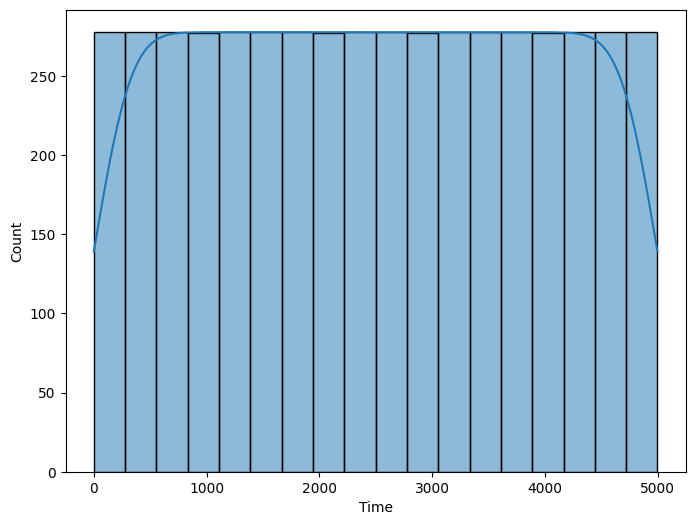

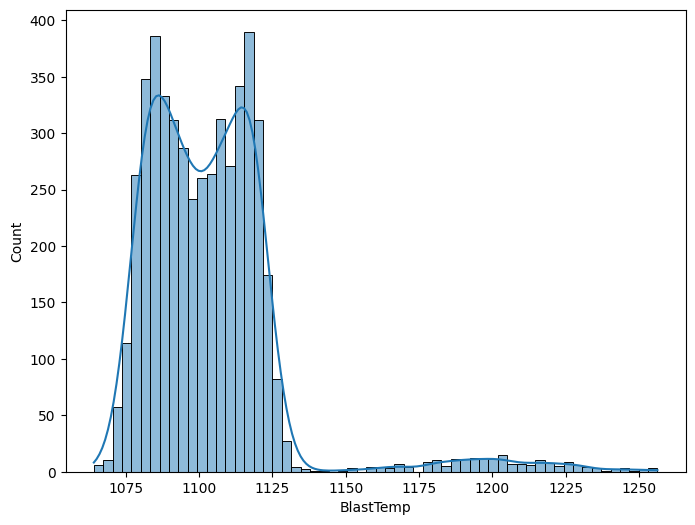

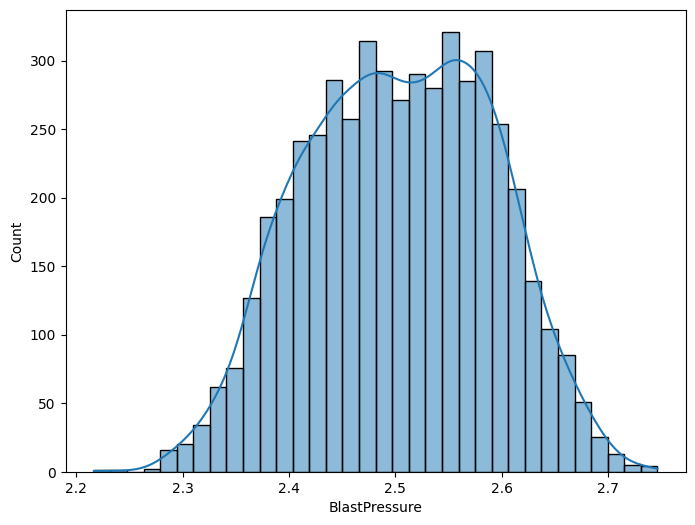

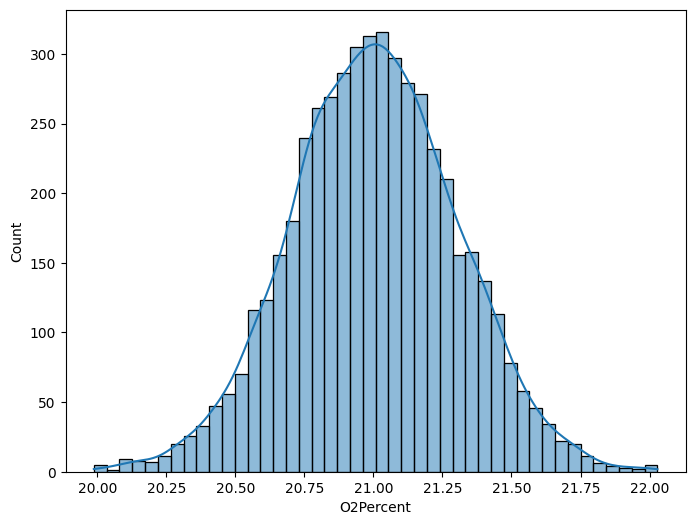

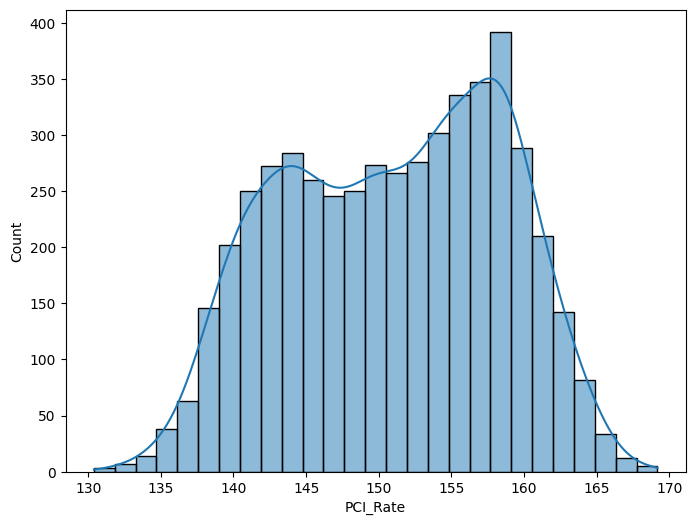

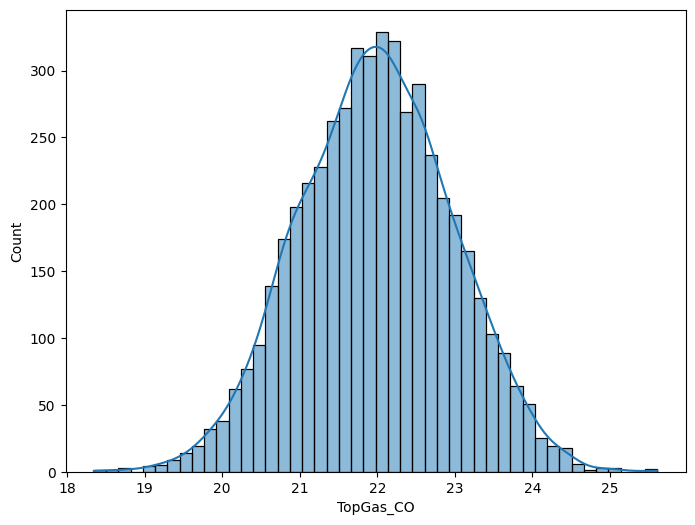

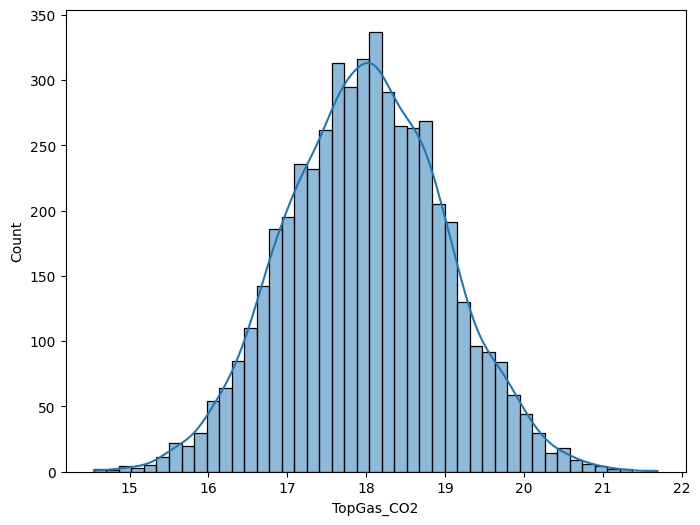

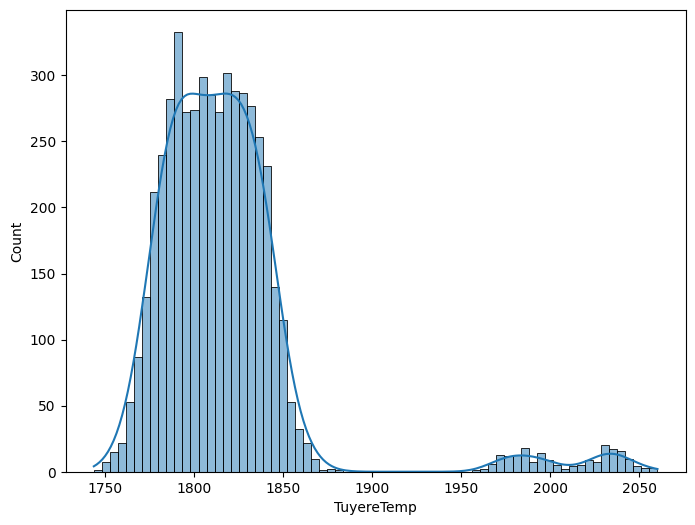

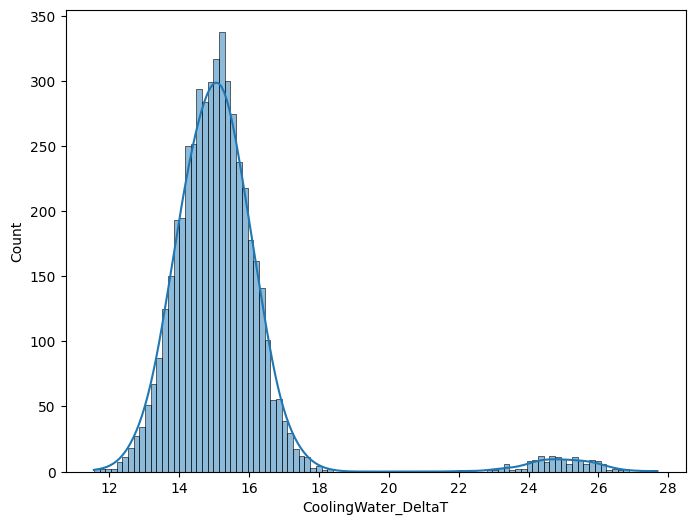

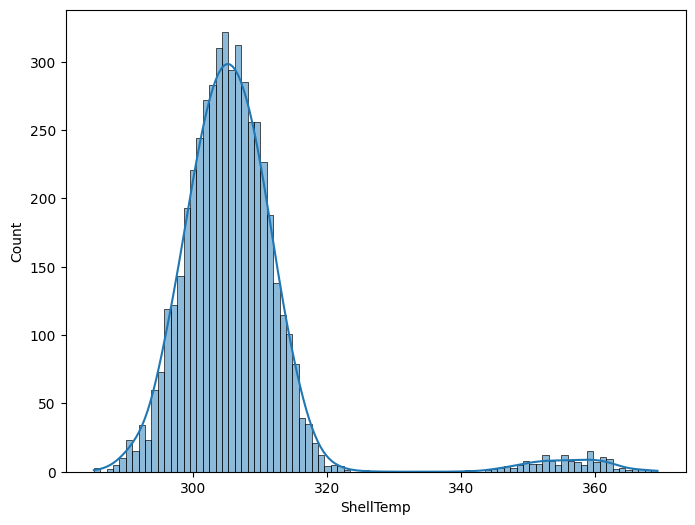

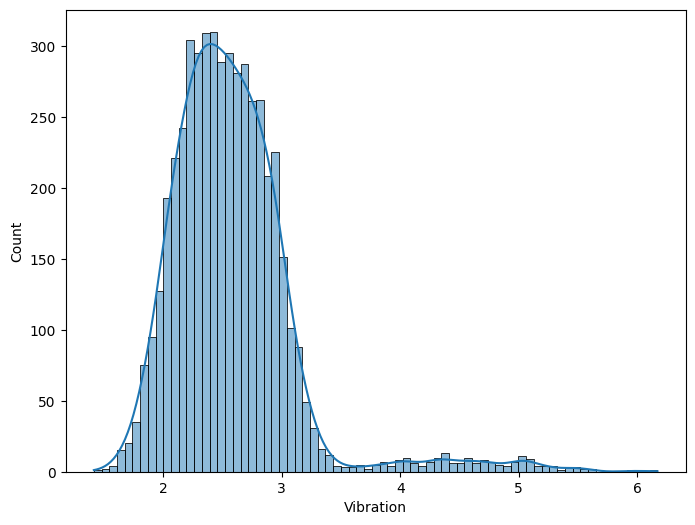

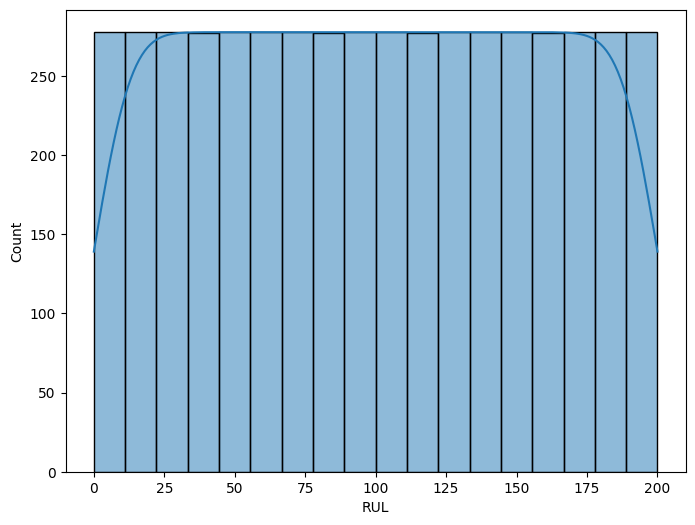

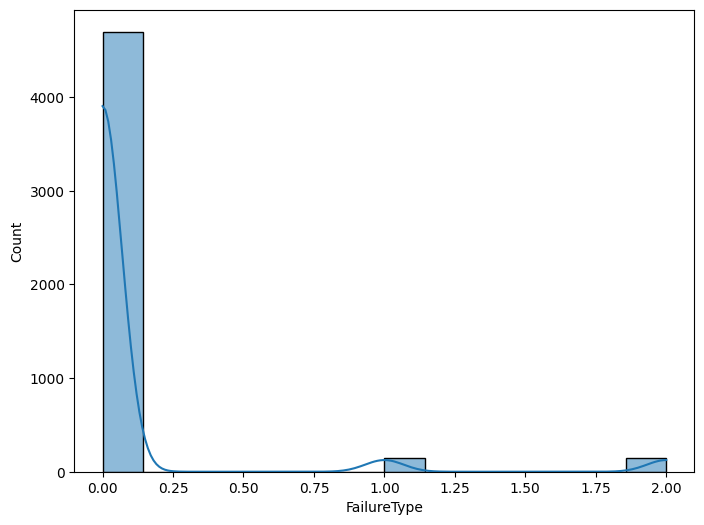

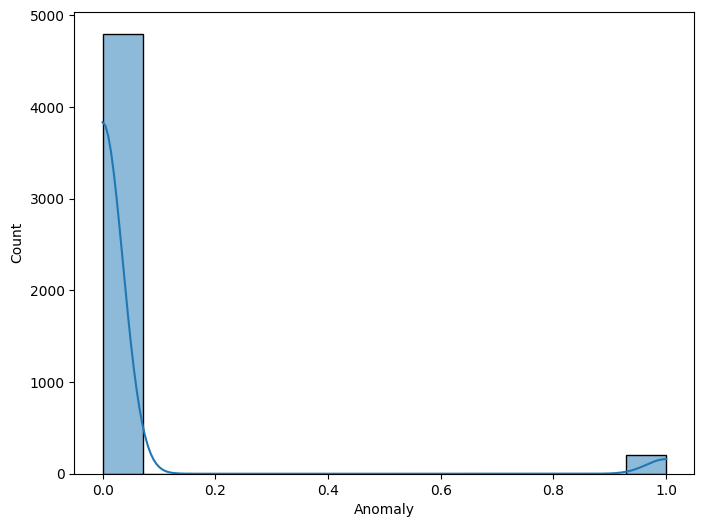

In [ ]:
import matplotlib.pyplot as plt
import seaborn as sns
for i in df.columns:
    plt.figure(figsize=(8, 6))
    sns.histplot(df[i], kde=True)



In [ ]:
df.columns

Index(['Time', 'BlastTemp', 'BlastPressure', 'O2Percent', 'PCI_Rate',
       'TopGas_CO', 'TopGas_CO2', 'TuyereTemp', 'CoolingWater_DeltaT',
       'ShellTemp', 'Vibration', 'RUL', 'FailureType', 'Anomaly'],
      dtype='object')

define feature

In [ ]:
df_model = df.copy()

df_model = df_model.drop(columns=['Time', 'FailureType', 'Anomaly','RUL'])

this is the step fof accure better accuracy

this the step to acquire best accuracy droping the anomaly

In [ ]:
train_df = df[df['Anomaly']==0]
test_df = df.copy()

In [ ]:
features = ['BlastTemp', 'BlastPressure', 'O2Percent', 'PCI_Rate',
       'TopGas_CO', 'TopGas_CO2', 'TuyereTemp', 'CoolingWater_DeltaT',
       'ShellTemp', 'Vibration']

scalling

In [ ]:
from sklearn.preprocessing import StandardScaler

scaler = StandardScaler()
x_train = scaler.fit_transform(train_df[features])
x_test = scaler.transform(test_df[features])
y_true = (test_df['Anomaly'] == 1).astype(int)

defining model

In [ ]:
from sklearn.ensemble import IsolationForest

iso = IsolationForest(
    n_estimators=100,
    contamination=0.01,
    max_samples=0.5,
    max_features=0.7,
    bootstrap=True,
    random_state=42
)

iso.fit(x_train)

IsolationForest(bootstrap=True, contamination=0.01, max_features=0.7,
                max_samples=0.5, random_state=42)

dumping model for use in dashboard

In [ ]:
import joblib
joblib.dump(iso, 'anomaly_model.pkl')

['anomaly_model.pkl']

In [ ]:
test_df["Anomaly_score"] = - iso.decision_function(x_test)
test_df["Anomaly_score"]

,Anomaly_score
0,-0.186518
1,-0.168302
2,-0.180808
3,-0.190915
4,-0.165046
...,...
4995,-0.144039
4996,-0.147324
4997,-0.149180
4998,-0.139962


In [ ]:
from sklearn.metrics import classification_report, confusion_matrix,roc_curve,precision_recall_curve,f1_score,auc,ConfusionMatrixDisplay

In [ ]:
y_score = test_df['Anomaly_score'].values

In [ ]:
fpr,tpr,thresholds = roc_curve(y_true,y_score)
roc_auc = auc(fpr,tpr)
#

In [ ]:
prec,rec,Pr_thresholds = precision_recall_curve(y_true,y_score)

In [ ]:
pr_auc = auc(rec,prec)

In [ ]:
f1_scores = 2*prec*rec/(prec+rec)+1e-9
#

In [ ]:
best_index = np.argmax(f1_scores)
best_threshold = Pr_thresholds[best_index]

In [ ]:
test_df['anomaly_flag'] = (test_df['Anomaly_score'] > best_threshold).astype(int)
#

In [ ]:
classification_report(y_true,test_df['anomaly_flag'])
#

'              precision    recall  f1-score   support\n\n           0       1.00      0.95      0.97      4800\n           1       0.44      0.97      0.61       200\n\n    accuracy                           0.95      5000\n   macro avg       0.72      0.96      0.79      5000\nweighted avg       0.98      0.95      0.96      5000\n'

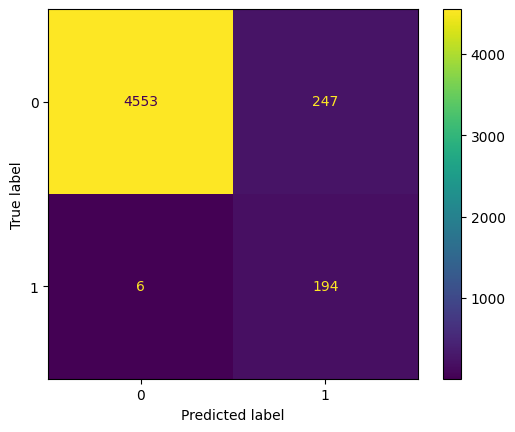

In [ ]:
ConfusionMatrixDisplay(confusion_matrix(y_true,test_df['anomaly_flag'])).plot()
#

In [ ]:
import numpy as np
from sklearn.preprocessing import StandardScaler

# Scale
scaler = StandardScaler()
X_scaled = scaler.fit_transform(x_train)

In [ ]:
import numpy as np
import tensorflow as tf
from tensorflow.keras.models import Model, Sequential
from tensorflow.keras.layers import Input, Dense

def buildautoencoder(input_dim):
  Encoder = Sequential([Dense(32, activation='relu', input_shape=(input_dim,)),
                        Dense(16, activation='relu'),
                        Dense(8, activation='relu')])
  Decoder = Sequential([Dense(16, activation='relu', input_shape=(8,)),
                        Dense(32, activation='relu'),
                        Dense(input_dim, activation='sigmoid')])
  inputs = Input(shape=(input_dim,))
  Latent = Encoder(inputs)
  Output = Decoder(Latent)

  return Model(inputs, Output),Encoder
input_dim = x_train.shape[1]
autoencoder,encoder = buildautoencoder(input_dim)
autoencoder.compile(optimizer='adam', loss='mse')
#

/usr/local/lib/python3.12/dist-packages/keras/src/layers/core/dense.py:106: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


In [ ]:
autoencoder.fit(x_train,X_scaled,
    epochs=50,
    batch_size=32,
    validation_split=0.1,
    verbose=1
)

Epoch 1/50
135/135 ━━━━━━━━━━━━━━━━━━━━ 2s 4ms/step - loss: 1.0738 - val_loss: 1.2074
Epoch 2/50
135/135 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - loss: 0.8204 - val_loss: 1.1204
Epoch 3/50
135/135 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - loss: 0.7776 - val_loss: 1.1049
Epoch 4/50
135/135 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - loss: 0.7434 - val_loss: 1.0766
Epoch 5/50
135/135 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - loss: 0.7168 - val_loss: 1.0688
Epoch 6/50
135/135 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - loss: 0.6993 - val_loss: 1.0604
Epoch 7/50
135/135 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - loss: 0.6815 - val_loss: 1.0272
Epoch 8/50
135/135 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - loss: 0.6667 - val_loss: 1.0248
Epoch 9/50
135/135 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - loss: 0.6626 - val_loss: 1.0214
Epoch 10/50
135/135 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - loss: 0.6585 - val_loss: 1.0321
Epoch 11/50
135/135 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - loss: 0.6506 - val_loss: 1.0252
Epoch 12/50
135/135 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step

In [ ]:
recons = autoencoder.predict(x_test)
mse = np.mean(np.power(x_test - recons, 2), axis=1)

df['ae_error'] = mse

157/157 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step


In [ ]:
from sklearn.metrics import classification_report, confusion_matrix,roc_curve,precision_recall_curve,f1_score,auc,ConfusionMatrixDisplay

In [ ]:
y_pred = df['ae_error']

In [ ]:
fp,tp,thres = roc_curve(y_true,y_pred)
roc_auc = auc(fp,tp)

In [ ]:
pre,re,Pr_thres = precision_recall_curve(y_true,y_pred)

In [ ]:
pr_auc = auc(re,pre)

In [ ]:
f1_sco = 2*pre*re/(pre+re)+1e-9

In [ ]:
best_ind = np.argmax(f1_scores)
best_thres = Pr_thres[best_ind]

In [ ]:
test_df['anomaly_sign'] = (df['ae_error'] > best_thres).astype(int)

In [ ]:
classification_report(y_true,test_df['anomaly_sign'])

'              precision    recall  f1-score   support\n\n           0       1.00      0.96      0.98      4800\n           1       0.49      1.00      0.66       200\n\n    accuracy                           0.96      5000\n   macro avg       0.75      0.98      0.82      5000\nweighted avg       0.98      0.96      0.97      5000\n'

In [ ]:
threshold = np.percentile(mse, 95)  # top 5% anomalies

df['ae_anomaly'] = (df['ae_error'] > threshold).astype(int)

In [ ]:
from sklearn.metrics import classification_report, confusion_matrix

print(confusion_matrix(df['Anomaly'], test_df['anomaly_sign']))
print(classification_report(df['Anomaly'], test_df['anomaly_sign']))

[[4594  206]
 [   0  200]]
              precision    recall  f1-score   support

         0.0       1.00      0.96      0.98      4800
         1.0       0.49      1.00      0.66       200

    accuracy                           0.96      5000
   macro avg       0.75      0.98      0.82      5000
weighted avg       0.98      0.96      0.97      5000



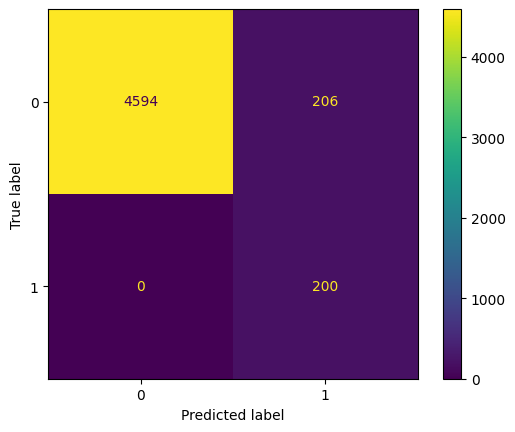

In [ ]:
ConfusionMatrixDisplay(confusion_matrix(y_true,test_df['anomaly_sign'])).plot()

In [ ]:
test_df['final_anomaly'] = (
    (test_df['anomaly_flag'] == 1) | (test_df['anomaly_sign'] == 1)
).astype(int)

In [ ]:
from sklearn.metrics import classification_report, confusion_matrix

print(confusion_matrix(df['Anomaly'], test_df['final_anomaly']))
print(classification_report(df['Anomaly'], test_df['final_anomaly']))

[[4560  240]
 [   0  200]]
              precision    recall  f1-score   support

         0.0       1.00      0.95      0.97      4800
         1.0       0.45      1.00      0.62       200

    accuracy                           0.95      5000
   macro avg       0.73      0.97      0.80      5000
weighted avg       0.98      0.95      0.96      5000



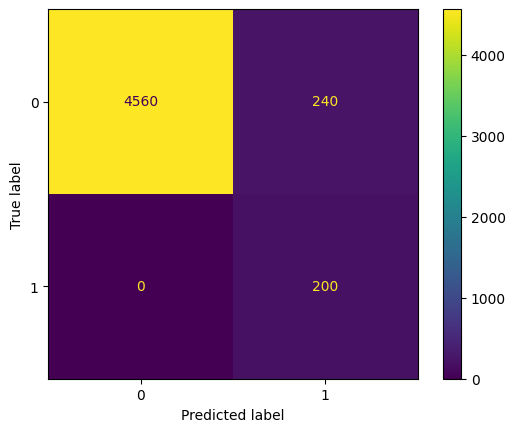

In [ ]:
ConfusionMatrixDisplay(confusion_matrix(y_true,test_df['final_anomaly'])).plot()

In [ ]:
from sklearn.metrics import accuracy_score

accuracy = accuracy_score(df['Anomaly'], test_df['final_anomaly'])
print("Accuracy:", accuracy)

Accuracy: 0.952


In [ ]:
print(df['Anomaly'].value_counts())

Anomaly
0.0    4800
1.0     200
Name: count, dtype: int64


In [ ]:
print(df['final_anomaly'].value_counts())

final_anomaly
0    4561
1     439
Name: count, dtype: int64


In [ ]:
from sklearn.ensemble import IsolationForest
from sklearn.metrics import f1_score

best_score = -1
best_params = None
best_model = None

param_grid = {
    'n_estimators': [100, 200, 300],
    'max_samples': [0.5, 0.7, 0.9],
    'contamination': [0.01, 0.03, 0.05],
    'max_features': [0.7, 0.9, 1.0],
    'bootstrap': [True, False]
}

# Loop over all combinations
for n in param_grid['n_estimators']:
    for ms in param_grid['max_samples']:
        for cont in param_grid['contamination']:
            for mf in param_grid['max_features']:
              for bs in param_grid['bootstrap']:

                  model = IsolationForest(
                      n_estimators=n,
                      max_samples=ms,
                      contamination=cont,
                      max_features=mf,
                      random_state=42
                  )

                  model.fit(x_train)

                # Predict
                  y_pred = model.predict(x_test)

                  # Convert (1 → anomaly = 1)
                  y_pred = [1 if x == 1 else 0 for x in y_pred]

                # Evaluate
                  score = f1_score(y_true, y_pred)

                  if score > best_score:
                      best_score = score
                      best_params = {
                          'n_estimators': n,
                          'max_samples': ms,
                          'contamination': cont,
                          'max_features': mf
                        }
                      best_model = model

print("Best Params:", best_params)
print("Best F1 Score:", best_score)

Best Params: {'n_estimators': 100, 'max_samples': 0.5, 'contamination': 0.01, 'max_features': 0.7}
Best F1 Score: 0.07089988313206078


In [ ]:
from sklearn.ensemble import IsolationForest
from sklearn.model_selection import GridSearchCV

# Model
iso = IsolationForest(random_state=42)

# Parameter grid
param_grid = {
    'n_estimators': [100, 200],
    'max_samples': [0.5, 0.7],
    'contamination': [0.01, 0.03],
    'max_features': [0.7, 0.9],
    'bootstrap': [True, False]
}

# Grid Search
grid = GridSearchCV(
    estimator=iso,
    param_grid=param_grid,
    scoring='f1',   # requires anomaly labels
    cv=2,
    n_jobs=-1,
    verbose=1
)

# Fit
grid.fit(x_test, y_true)

# Best model
best_iso = grid.best_estimator_

print("Best Params:", grid.best_params_)
print("Best Score:", grid.best_score_)
print("Best Model:", best_iso)

Fitting 2 folds for each of 32 candidates, totalling 64 fits


/usr/local/lib/python3.12/dist-packages/sklearn/model_selection/_search.py:1108: UserWarning: One or more of the test scores are non-finite: [nan nan nan nan nan nan nan nan nan nan nan nan nan nan nan nan nan nan
 nan nan nan nan nan nan nan nan nan nan nan nan nan nan]
  warnings.warn(


Best Params: {'bootstrap': True, 'contamination': 0.01, 'max_features': 0.7, 'max_samples': 0.5, 'n_estimators': 100}
Best Score: nan
